# 02 — Baseline Model

This notebook documents the pretrained baseline AMC model used in AMCShield.

The baseline checkpoint is loaded from:

`checkpoints/baseline_best.pt`

No additional training is performed in this notebook.

The notebook uses the previously generated evaluation results to analyze
baseline performance across the complete SNR range.

In [1]:
import torch
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

checkpoint_path = ROOT / "checkpoints/baseline_best.pt"

checkpoint = torch.load(
    checkpoint_path,
    map_location="cpu",
    weights_only=False
)

print("Checkpoint keys:")
print(checkpoint.keys())

print("\nEpoch:", checkpoint.get("epoch"))
print("Validation accuracy:", checkpoint.get("val_accuracy"))
print("Validation loss:", checkpoint.get("val_loss"))

Checkpoint keys:
dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_accuracy', 'val_loss', 'config'])

Epoch: 2
Validation accuracy: 0.3505553150088944
Validation loss: 2.1220751563275653


In [3]:
import sys

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.model_baseline import BaselineCNN

model = BaselineCNN()

model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

parameters = sum(p.numel() for p in model.parameters())

print("Model loaded successfully.")
print("Total parameters:", parameters)

Model loaded successfully.
Total parameters: 177496


In [4]:
clean = pd.read_csv(ROOT / "results/baseline_clean_results.csv")

display(clean)

,snr,clean_accuracy
0,-20,7.0312
1,-18,12.1094
2,-16,14.0625
3,-14,21.8750
4,-12,32.4219
5,-10,46.0938
6,-8,53.5156
7,-6,74.6094
8,-4,91.7969
9,-2,99.6094


In [5]:
fgsm = pd.read_csv(ROOT / "results/baseline_fgsm_results.csv")
pgd = pd.read_csv(ROOT / "results/baseline_pgd_results.csv")
mim = pd.read_csv(ROOT / "results/baseline_mim_results.csv")
cw = pd.read_csv(ROOT / "results/baseline_cw_results.csv")
blackbox = pd.read_csv(ROOT / "results/baseline_blackbox_results.csv")

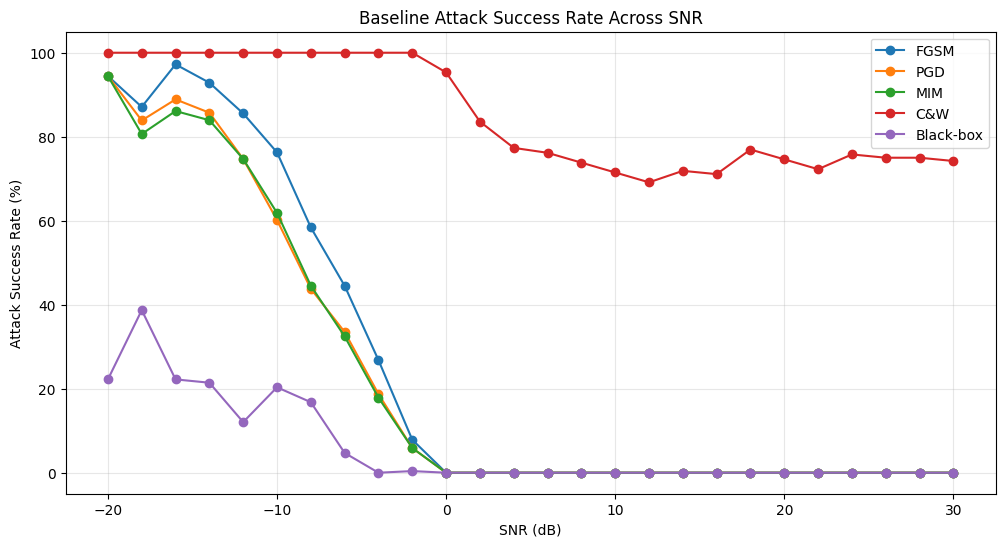

In [6]:
plt.figure(figsize=(12, 6))

plt.plot(fgsm["snr"], fgsm["attack_success_rate"], marker="o", label="FGSM")
plt.plot(pgd["snr"], pgd["attack_success_rate"], marker="o", label="PGD")
plt.plot(mim["snr"], mim["attack_success_rate"], marker="o", label="MIM")
plt.plot(cw["snr"], cw["attack_success_rate"], marker="o", label="C&W")
plt.plot(
    blackbox["snr"],
    blackbox["attack_success_rate"],
    marker="o",
    label="Black-box"
)

plt.xlabel("SNR (dB)")
plt.ylabel("Attack Success Rate (%)")
plt.title("Baseline Attack Success Rate Across SNR")
plt.legend()
plt.grid(alpha=0.3)
plt.show()